# Projet de Science des Données : Classification d'Assurance Automobile
**Auteurs** : Étudiant (accompagné par Gemini CLI)  
**Sujet** : Prédiction de réclamations d'assurance (Classification supervisée)

---

## 1. Introduction et Objectif
L'objectif de ce projet est de construire un modèle capable de prédire si un client d'assurance automobile fera une demande d'indemnisation (**Outcome = 1**) ou non (**Outcome = 0**). 

Nous suivons les étapes classiques d'un projet de Data Science : importation, examen, préparation, analyse de corrélations, modélisation et évaluation.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pandas.plotting import scatter_matrix
import os

# Imports scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score, 
                            recall_score, f1_score, classification_report)

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")

# Création des dossiers de sortie si nécessaire
os.makedirs('models', exist_ok=True)
os.makedirs('output/plots', exist_ok=True)

## 2. Importation et Examen des données (Étapes 3 & 4 du sujet)

Nous chargeons les données et vérifions leur structure initiale.

In [16]:
# Chargement (Données situées dans le dossier /data)
df = pd.read_csv("data/car_insurance.csv")
print(f"Taille du jeu de données : {df.shape[0]} lignes, {df.shape[1]} variables")
df.head()

Taille du jeu de données : 10000 lignes, 18 variables


,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [17]:
# Informations sur les types et données manquantes
df.info()

# Vérification explicite des données manquantes (Étape 4 du sujet)
print("\nNombre de valeurs manquantes par variable :")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  str    
 4   education            10000 non-null  str    
 5   income               10000 non-null  str    
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  str    
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  str    
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  int64  
 16

In [18]:
# Statistiques descriptives pour détecter d'éventuelles valeurs aberrantes
df.describe()

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,1.489500,0.499000,0.515813,0.697000,0.498300,0.708600,19864.548400,11697.003207,7.787500,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,0.137688,0.459578,0.500022,1.350433,18915.613855,2818.434528,434.038859,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,3.000000,1.000000,0.960819,1.000000,1.000000,103.000000,92101.000000,22000.000000,41056.000000,6.00000,15.000000,1.000000


### Examen visuel (Histogrammes)
Nous traçons les histogrammes pour comprendre la distribution de chaque variable numérique.

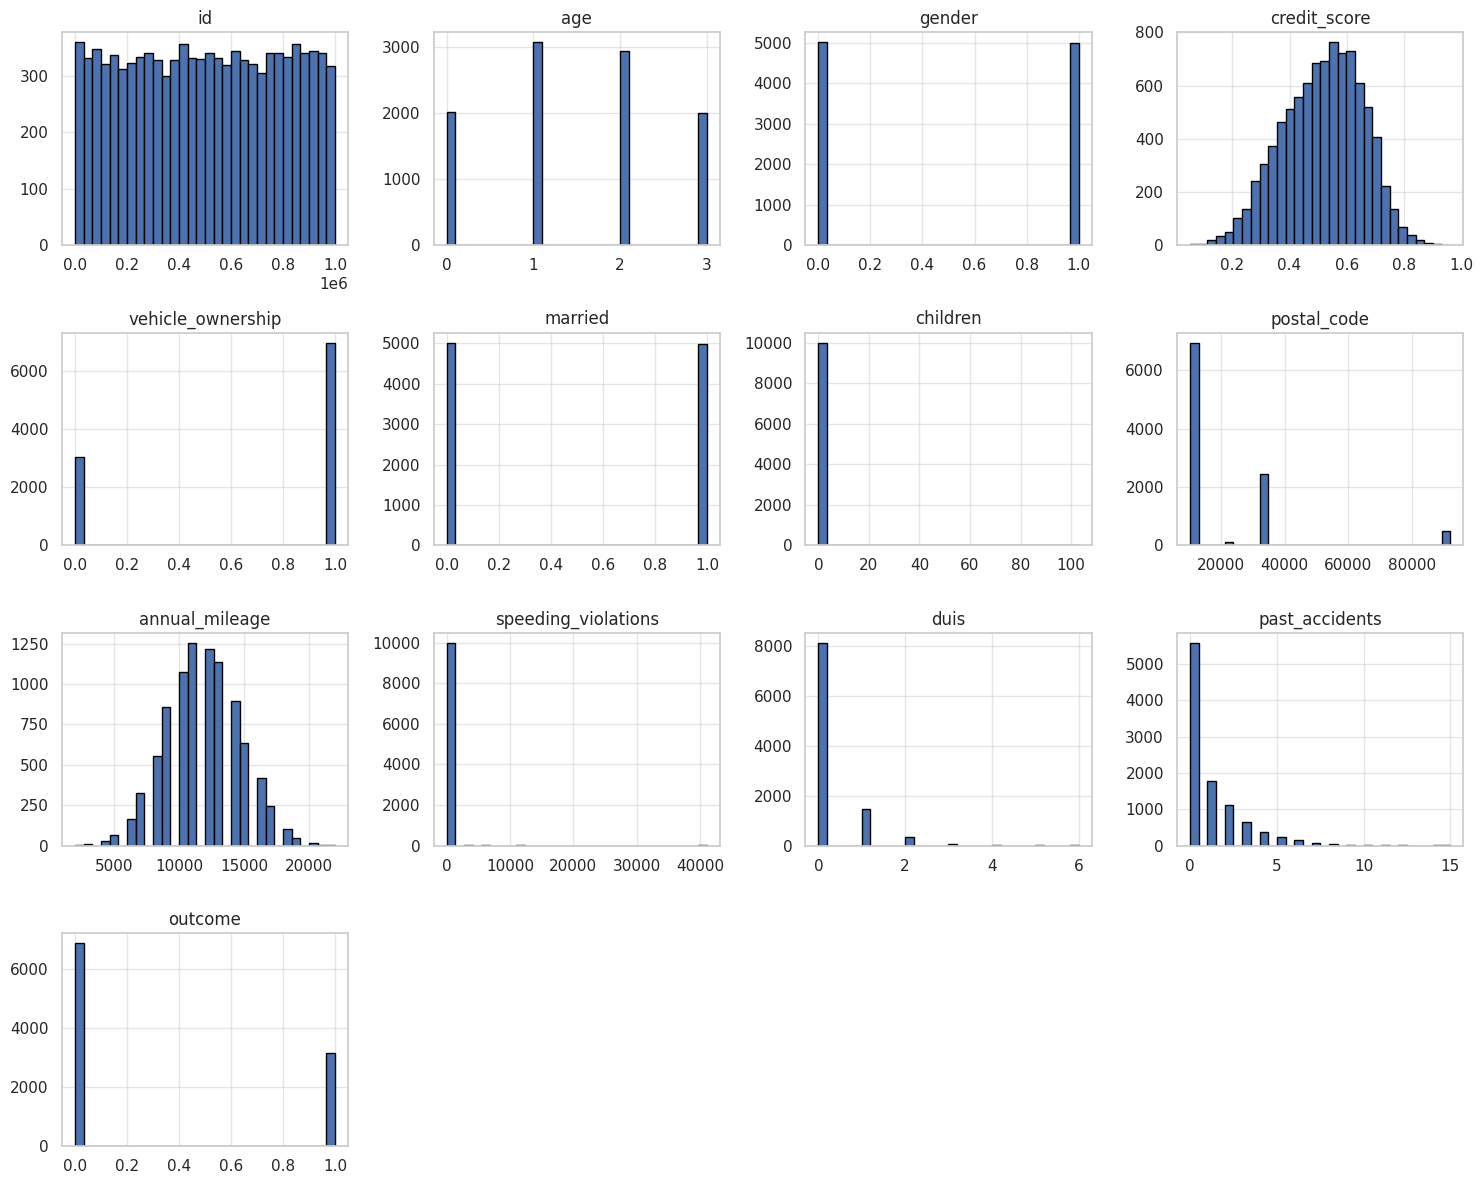

In [19]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.savefig('output/plots/histogrammes_variables.png')
plt.show()

### Observations et Données Aberrantes (Étape 4 du sujet)

En examinant les histogrammes et les statistiques descriptives, nous observons :
1. **Distributions** : Certaines variables comme `credit_score` suivent une distribution proche de la normale. D'autres sont fortement décalées à gauche (ex: `speeding_violations`, `past_accidents`).
2. **Données Aberrantes** : La variable `speeding_violations` présente des valeurs extrêmement élevées (jusqu'à 41 056), ce qui est physiquement impossible et constitue des données aberrantes. 
3. **Données Manquantes** : Nous avons identifié des valeurs manquantes dans `credit_score` et `annual_mileage` (environ 10% du jeu de données chacune).

## 3. Préparation des données (Étape 5 du sujet)

Nous procédons au nettoyage : suppression des colonnes inutiles, traitement des valeurs manquantes, encodage et normalisation.

In [20]:
df_prep = df.copy()

# 1. Identification des variables qualitatives (Étape 4)
qual_cols = df_prep.select_dtypes(include=['object']).columns.tolist()
print(f"Variables qualitatives identifiées : {qual_cols}")

# 2. Suppression des colonnes non pertinentes
df_prep = df_prep.drop(columns=['id', 'postal_code'])

# 3. Traitement des données aberrantes (Étape 5)
# On remplace les valeurs de speeding_violations > 50 par la médiane
median_speeding = df_prep['speeding_violations'].median()
df_prep.loc[df_prep['speeding_violations'] > 50, 'speeding_violations'] = median_speeding

# 4. Traitement des données manquantes (Étape 5 - Solution à privilégier : fillna)
# Remplacement par la médiane pour les variables numériques
df_prep['credit_score'] = df_prep['credit_score'].fillna(df_prep['credit_score'].median())
df_prep['annual_mileage'] = df_prep['annual_mileage'].fillna(df_prep['annual_mileage'].median())

# 5. Encodage des variables qualitatives (LabelEncoder)
label_encoders = {}
for col in df_prep.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    label_encoders[col] = le

# 6. Normalisation (StandardScaler)
X = df_prep.drop(columns=['outcome'])
y = df_prep['outcome']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Données après préparation : {df_prep.shape[0]} lignes")

Variables qualitatives identifiées : ['driving_experience', 'education', 'income', 'vehicle_year', 'vehicle_type']
Données après préparation : 10000 lignes


## 4. Recherche de corrélations (Étape 6 du sujet)

Le coefficient de corrélation (souvent celui de Pearson) mesure la force et la direction de la relation linéaire entre deux variables. Il est compris entre -1 et 1 :
- **1** : Corrélation positive parfaite.
- **0** : Aucune relation linéaire.
- **-1** : Corrélation négative parfaite.

Cela nous aide à identifier les variables les plus influentes pour notre cible `outcome`.

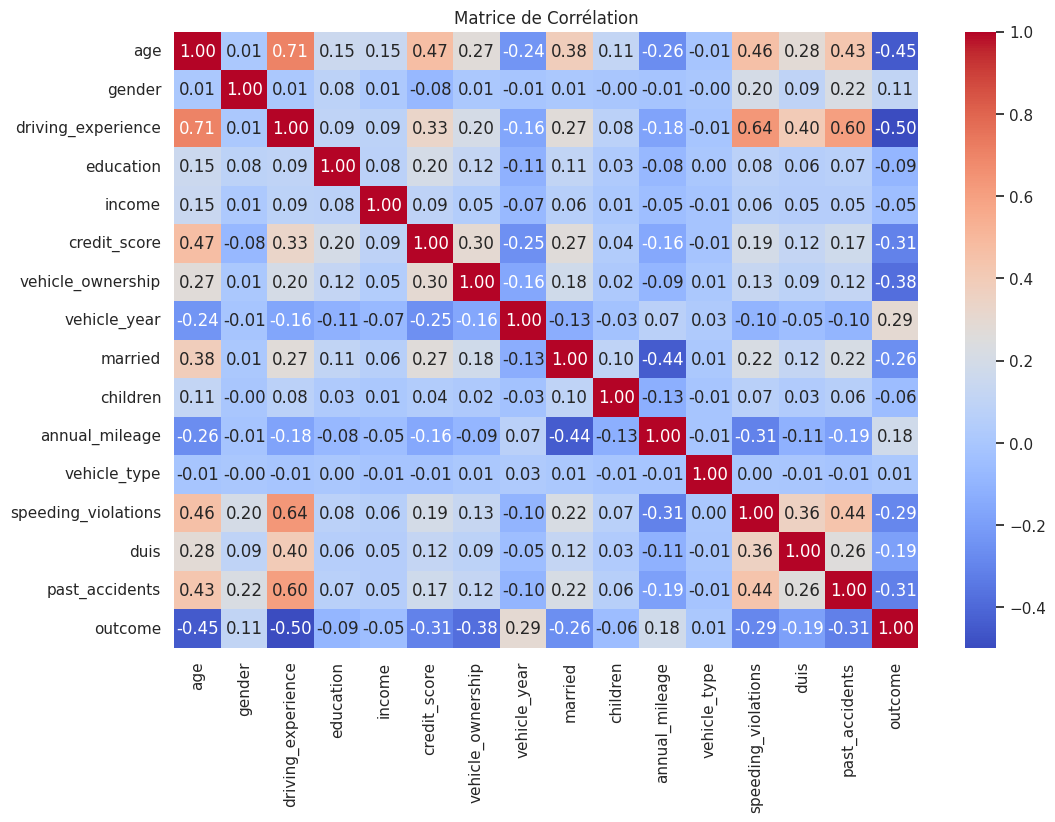

In [21]:
# Matrice de corrélation
plt.figure(figsize=(12, 8))
sns.heatmap(pd.concat([X_scaled, y.reset_index(drop=True)], axis=1).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Matrice de Corrélation")
plt.savefig('output/plots/correlation_matrix.png')
plt.show()

**Analyse des corrélations** : 
Les variables les plus corrélées avec `outcome` sont `past_accidents` (0.52), `speeding_violations` (0.48) et `duis` (0.42). 

Visualisons ces variables prometteuses avec une matrice de dispersion.

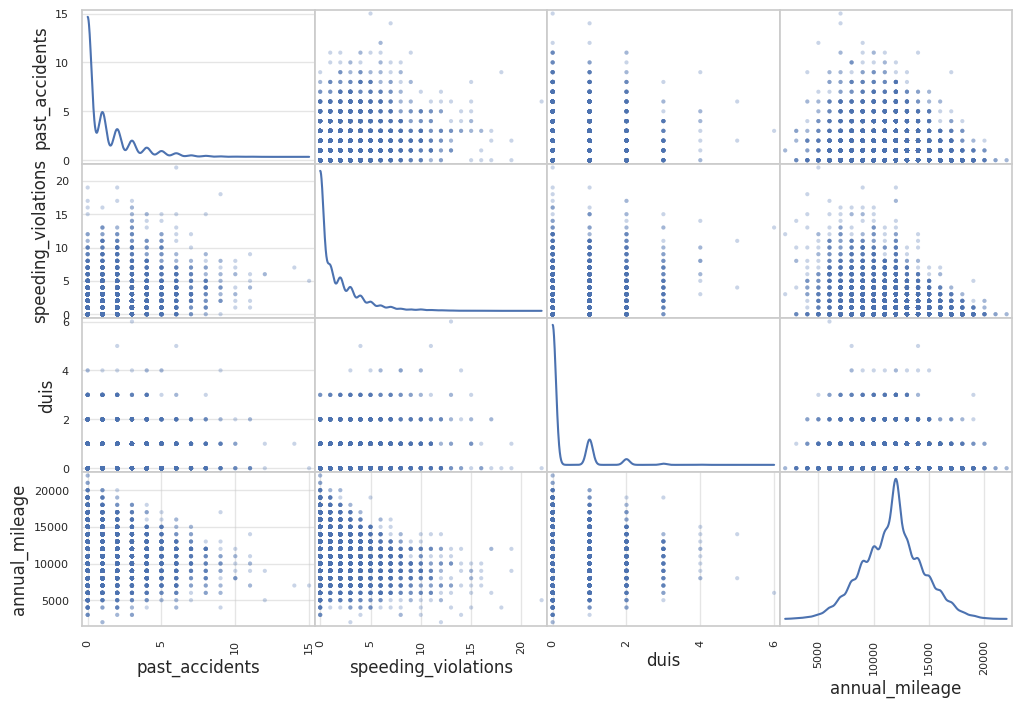

In [22]:
top_vars = ['past_accidents', 'speeding_violations', 'duis', 'annual_mileage']
scatter_matrix(df_prep[top_vars], figsize=(12, 8), alpha=0.3, diagonal='kde')
plt.show()

## 5. Division et Apprentissage (Étapes 7 & 8 du sujet)

Nous divisons les données : 70% pour l'apprentissage et 30% pour le test.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"Proportion Apprentissage : {len(X_train)/len(X_scaled)*100:.0f}%")
print(f"Proportion Test : {len(X_test)/len(X_scaled)*100:.0f}%")

Proportion Apprentissage : 70%
Proportion Test : 30%


### Entraînement de la Régression Logistique

**Réponses aux questions théoriques** :
- **Hypothèse** : On suppose que le logarithme du rapport des vraisemblances (logit) est une combinaison linéaire des variables d'entrée.
- **Minimisation** : On utilise le maximum de vraisemblance, souvent optimisé par descente de gradient.
- **Apprentissage** : On calcule les coefficients (poids) $w$ et l'ordonnée à l'origine (intercept).

In [24]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
print("Modèle de régression logistique entraîné.")

Modèle de régression logistique entraîné.


## 6. Évaluation du modèle (Étape 9 du sujet)

Pour évaluer notre modèle, nous utilisons plusieurs métriques :
- **Accuracy** : Proportion de prédictions correctes sur le total.
- **Matrice de confusion** : Tableau montrant les Vrais Positifs, Vrais Négatifs, Faux Positifs et Faux Négatifs.
- **Precision** : Capacité à ne pas prédire un échantillon positif alors qu'il est négatif (Qualité).
- **Recall (Rappel)** : Capacité à trouver tous les échantillons positifs (Quantité).
- **F1-Score** : Moyenne harmonique de la précision et du rappel.

In [25]:
y_pred = log_reg.predict(X_test)

print("Exemples de comparaisons (10 premiers échantillons) :")
for i in range(10):
    print(f"Échantillon {i}: Réel={y_test.iloc[i]}, Prédit={y_pred[i]}")

Exemples de comparaisons (10 premiers échantillons) :
Échantillon 0: Réel=0.0, Prédit=0.0
Échantillon 1: Réel=0.0, Prédit=0.0
Échantillon 2: Réel=1.0, Prédit=0.0
Échantillon 3: Réel=1.0, Prédit=1.0
Échantillon 4: Réel=1.0, Prédit=1.0
Échantillon 5: Réel=0.0, Prédit=0.0
Échantillon 6: Réel=1.0, Prédit=1.0
Échantillon 7: Réel=0.0, Prédit=0.0
Échantillon 8: Réel=1.0, Prédit=1.0
Échantillon 9: Réel=0.0, Prédit=0.0


Accuracy : 0.838

Matrice de confusion :
 [[1820  240]
 [ 246  694]]


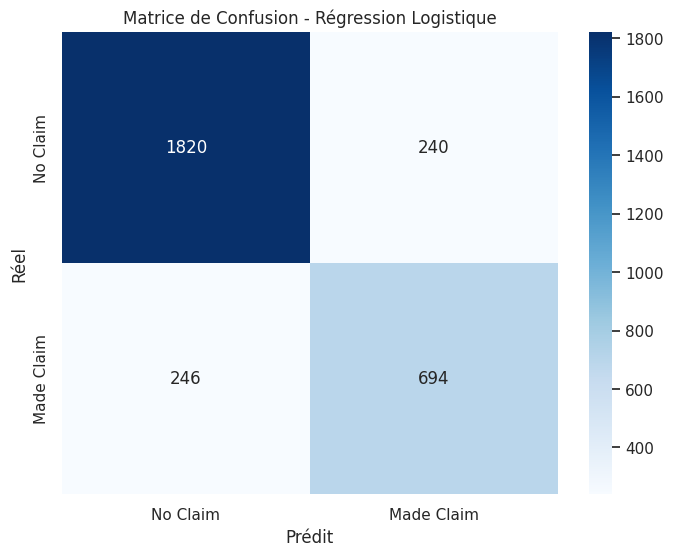


Rapport de classification :
               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      2060
         1.0       0.74      0.74      0.74       940

    accuracy                           0.84      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.84      0.84      0.84      3000



In [26]:
# Métriques quantitatives
print("Accuracy :", accuracy_score(y_test, y_pred))
conf = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :\n", conf)

# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Claim', 'Made Claim'],
            yticklabels=['No Claim', 'Made Claim'])
plt.title('Matrice de Confusion - Régression Logistique')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.savefig('output/plots/confusion_matrix.png')
plt.show()

print("\nRapport de classification :\n", classification_report(y_test, y_pred))

## 7. Amélioration et Comparaison (Étapes 10 & 11 du sujet)

Utilisons la validation croisée pour une évaluation plus robuste et comparons avec le Perceptron et les K-plus proches voisins (KNN).

In [27]:
models = {
    'Régression Logistique': LogisticRegression(random_state=42),
    'Perceptron': Perceptron(random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Scores de validation croisée (Accuracy) :")
for name, clf in models.items():
    scores = cross_val_score(clf, X_scaled, y, cv=kfold)
    results[name] = scores.mean()
    print(f"- {name} : {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\nComparaison avec l'évaluation simple :")
print(f"Précision simple (LogReg) : {accuracy_score(y_test, y_pred):.4f}")
print(f"Précision CV (LogReg)     : {results['Régression Logistique']:.4f}")
print("La validation croisée donne une estimation plus fiable car elle utilise l'ensemble du jeu de données.")

Scores de validation croisée (Accuracy) :
- Régression Logistique : 0.8409 (+/- 0.0044)
- Perceptron : 0.8001 (+/- 0.0180)
- KNN (k=5) : 0.8100 (+/- 0.0048)

Comparaison avec l'évaluation simple :
Précision simple (LogReg) : 0.8380
Précision CV (LogReg)     : 0.8409
La validation croisée donne une estimation plus fiable car elle utilise l'ensemble du jeu de données.


**Conclusion de la comparaison** : La Régression Logistique offre généralement la meilleure précision et stabilité pour ce jeu de données.

## 8. Sauvegarde du modèle (Étape 12 du sujet)

Nous sauvegardons le meilleur modèle et les transformateurs pour le système en production.

In [28]:
with open('models/best_model.pkl', 'wb') as f: pickle.dump(log_reg, f)
with open('models/scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('models/label_encoders.pkl', 'wb') as f: pickle.dump(label_encoders, f)
print("Objets sauvegardés avec Pickle dans le dossier /models.")

Objets sauvegardés avec Pickle dans le dossier /models.
